## Aplicación de las técnicas de reducción de dimensiones en el dataset Heart

In [1]:
# Imports y comprobaciones iniciales
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.manifold import TSNE
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score, adjusted_rand_score
from sklearn.model_selection import train_test_split
import warnings
warnings.filterwarnings('ignore')
try:
    import umap
    UMAP_AVAILABLE = True
except ImportError:
    UMAP_AVAILABLE = False
    print('UMAP no está instalado. Para usarlo: pip install umap-learn')

# Leemos el archivo CSV con los datos de pacientes
df = pd.read_csv('heart.csv')
print('Dimensiones del dataset Heart:', df.shape)
print('Características del dataset Heart:', df.columns.tolist())
print(df.head())
# Configuración de estilo para gráficos
sns.set_style('whitegrid')
%matplotlib inline

Dimensiones del dataset Heart: (918, 12)
Características del dataset Heart: ['Age', 'Sex', 'ChestPainType', 'RestingBP', 'Cholesterol', 'FastingBS', 'RestingECG', 'MaxHR', 'ExerciseAngina', 'Oldpeak', 'ST_Slope', 'HeartDisease']
   Age Sex ChestPainType  RestingBP  Cholesterol  FastingBS RestingECG  MaxHR  \
0   40   M           ATA        140          289          0     Normal    172   
1   49   F           NAP        160          180          0     Normal    156   
2   37   M           ATA        130          283          0         ST     98   
3   48   F           ASY        138          214          0     Normal    108   
4   54   M           NAP        150          195          0     Normal    122   

  ExerciseAngina  Oldpeak ST_Slope  HeartDisease  
0              N      0.0       Up             0  
1              N      1.0     Flat             1  
2              N      0.0       Up             0  
3              Y      1.5     Flat             1  
4              N      0.0    

In [2]:
# Preparar datos
# Convertimos caracteristicas no numericas a dummies si es necesario
df = pd.get_dummies(df, drop_first=True)
print('Dimensiones tras get_dummies:', df.shape)
print('Características tras get_dummies:', df.columns.tolist())
print(df.head())


Dimensiones tras get_dummies: (918, 16)
Características tras get_dummies: ['Age', 'RestingBP', 'Cholesterol', 'FastingBS', 'MaxHR', 'Oldpeak', 'HeartDisease', 'Sex_M', 'ChestPainType_ATA', 'ChestPainType_NAP', 'ChestPainType_TA', 'RestingECG_Normal', 'RestingECG_ST', 'ExerciseAngina_Y', 'ST_Slope_Flat', 'ST_Slope_Up']
   Age  RestingBP  Cholesterol  FastingBS  MaxHR  Oldpeak  HeartDisease  \
0   40        140          289          0    172      0.0             0   
1   49        160          180          0    156      1.0             1   
2   37        130          283          0     98      0.0             0   
3   48        138          214          0    108      1.5             1   
4   54        150          195          0    122      0.0             0   

   Sex_M  ChestPainType_ATA  ChestPainType_NAP  ChestPainType_TA  \
0   True               True              False             False   
1  False              False               True             False   
2   True               Tr

Dimensiones originales: (918, 15)
Dimensiones tras PCA: (918, 2)
Varianza explicada (fractions): [0.226 0.11 ]


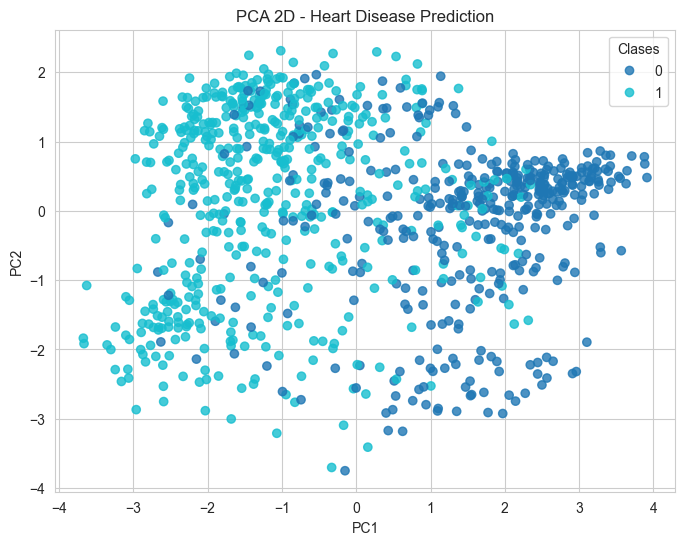

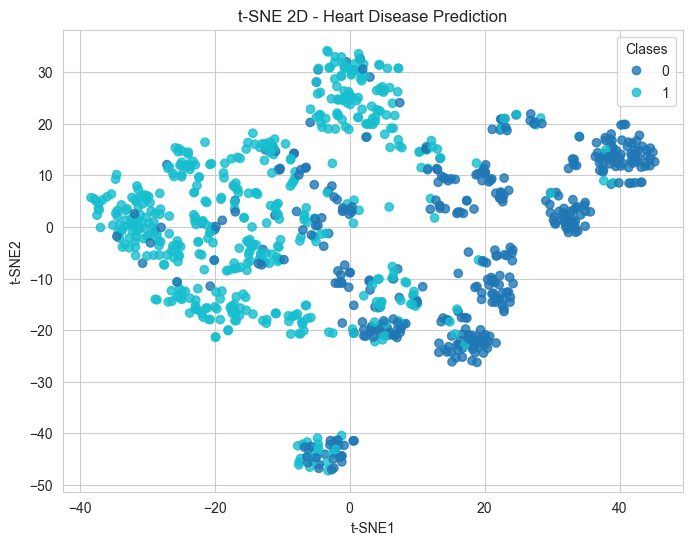

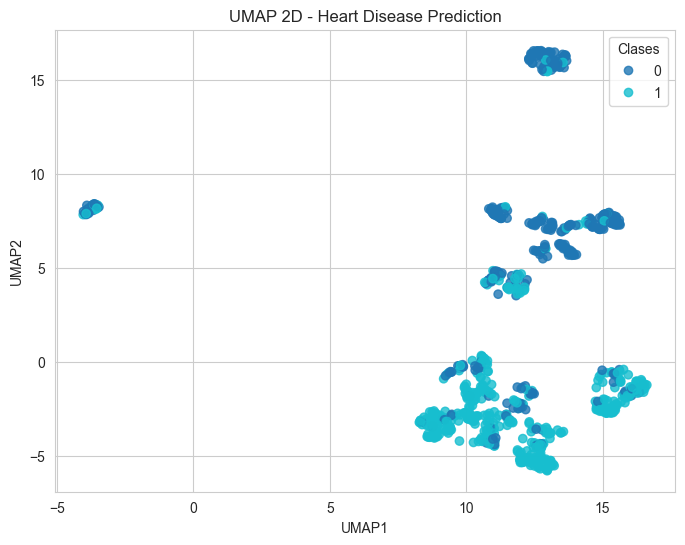

Adjusted Rand Index (k-Means en UMAP): 0.470
Silhouette Score (k-Means en UMAP): 0.578


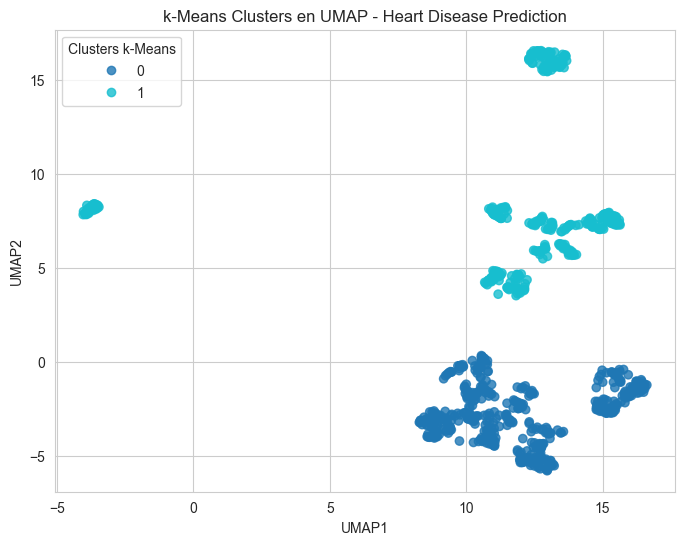

Adjusted Rand Index (Agglomerative en UMAP): 0.470
Silhouette Score (Agglomerative en UMAP): 0.578


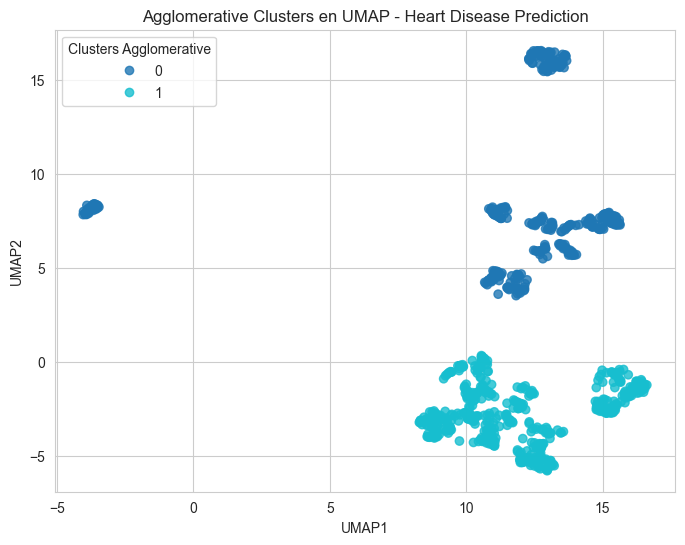

Adjusted Rand Index (DBSCAN en UMAP): 0.400
Silhouette Score (DBSCAN en UMAP): 0.687


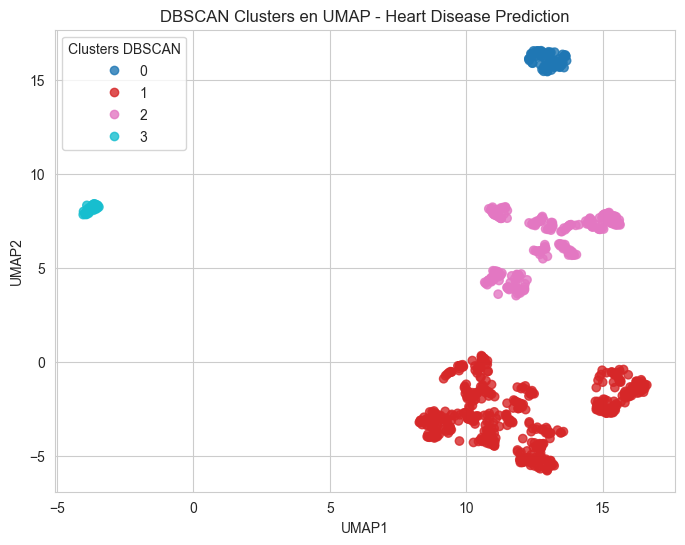

In [ ]:
# Separar características y target
X_heart = df.drop('HeartDisease', axis=1).values
y_heart = df['HeartDisease'].values

# Estandarizar características
X_heart_scaled = StandardScaler().fit_transform(X_heart) # Estandarizamos

# Calcular la disminución de dimensionalidad con PCA para mantener el 95% de la varianza
#pca_heart = PCA(n_components=0.95, random_state=42) # PCA para 95% varianza
#X_heart_pca = pca_heart.fit_transform(X_heart_scaled) # Datos reducidos
# para calcularlo e imprimir las dimensiones resultantes
#print('Dimensiones originales:', X_heart.shape)
#print('Dimensiones tras PCA (95% varianza):', X_heart_pca.shape)
#dimensiones_pca_heart = X_heart_pca.shape[1]

# PCA a Heart
dimensiones_pca_heart = 2  # Cambiar a 2D para visualización
pca_heart = PCA(n_components=dimensiones_pca_heart, random_state=42) # PCA a 2D
X_heart_pca = pca_heart.fit_transform(X_heart_scaled) # Datos reducidos

print('Dimensiones originales:', X_heart.shape)
print('Dimensiones tras PCA:', X_heart_pca.shape)
print('Varianza explicada (fractions):', np.round(pca_heart.explained_variance_ratio_, 3))

plt.figure(figsize=(8,6))
scatter = plt.scatter(X_heart_pca[:,0], X_heart_pca[:,1], c=y_heart, cmap='tab10', alpha=0.8)
plt.title('PCA 2D - Heart Disease Prediction')
plt.xlabel('PC1')
plt.ylabel('PC2')
# Leyenda para clases
plt.legend(*scatter.legend_elements(), title='Clases')
plt.show()

# t-SNE a heart
tsne_heart = TSNE(n_components=dimensiones_pca_heart, perplexity=30, random_state=42) # Instanciamos t-SNE
X_heart_tsne = tsne_heart.fit_transform(X_heart_scaled) # Aplicamos t-SNE

# Visualizamos los resultados
plt.figure(figsize=(8,6))
scatter = plt.scatter(X_heart_tsne[:,0], X_heart_tsne[:,1], c=y_heart, cmap='tab10', alpha=0.8)
plt.title('t-SNE 2D - Heart Disease Prediction')
plt.xlabel('t-SNE1')
plt.ylabel('t-SNE2')
# Leyenda para clases
plt.legend(*scatter.legend_elements(), title='Clases')
plt.show()

# UMAP a heart (si está disponible)
if UMAP_AVAILABLE:
    umap_reducer_heart = umap.UMAP(n_components=dimensiones_pca_heart, random_state=42) # Instanciamos UMAP
    X_heart_umap = umap_reducer_heart.fit_transform(X_heart_scaled) # Aplicamos UMAP

    # Visualizamos los resultados
    plt.figure(figsize=(8,6))
    scatter = plt.scatter(X_heart_umap[:,0], X_heart_umap[:,1], c=y_heart, cmap='tab10', alpha=0.8)
    plt.title('UMAP 2D - Heart Disease Prediction')
    plt.xlabel('UMAP1')
    plt.ylabel('UMAP2')
    # Leyenda para clases
    plt.legend(*scatter.legend_elements(), title='Clases')
    plt.show()
    
    # k-Means en UMAP
    kmeans_umap = KMeans(n_clusters=2, random_state=42)
    y_umap_kmeans = kmeans_umap.fit_predict(X_heart_umap)
    ari_umap = adjusted_rand_score(y_heart, y_umap_kmeans)
    print(f'Adjusted Rand Index (k-Means en UMAP): {ari_umap:.3f}')
    # Silhouette Score
    sil_umap = silhouette_score(X_heart_umap, y_umap_kmeans)
    print(f'Silhouette Score (k-Means en UMAP): {sil_umap:.3f}')    
    
    # Visualizamos clusters k-Means en UMAP
    plt.figure(figsize=(8,6))
    scatter = plt.scatter(X_heart_umap[:,0], X_heart_umap[:,1], c=y_umap_kmeans, cmap='tab10', alpha=0.8) 
    plt.title('k-Means Clusters en UMAP - Heart Disease Prediction')
    plt.xlabel('UMAP1')
    plt.ylabel('UMAP2')
    # Leyenda robusta para clusters
    plt.legend(*scatter.legend_elements(), title='Clusters k-Means')
    plt.show()      
    
    # Clustering jerarquico en UMAP
    from sklearn.cluster import AgglomerativeClustering
    agglo_umap = AgglomerativeClustering(n_clusters=2, linkage='complete')
    y_umap_agglo = agglo_umap.fit_predict(X_heart_umap)
    ari_agglo = adjusted_rand_score(y_heart, y_umap_agglo)
    print(f'Adjusted Rand Index (Agglomerative en UMAP): {ari_agglo:.3f}')
    # Silhouette Score
    sil_agglo = silhouette_score(X_heart_umap, y_umap_agglo)
    print(f'Silhouette Score (Agglomerative en UMAP): {sil_agglo:.3f}')
# Visualizar clusters con clustering jerárquico en UMAP
    plt.figure(figsize=(8,6))
    scatter = plt.scatter(X_heart_umap[:,0], X_heart_umap[:,1], c=y_umap_agglo, cmap='tab10', alpha=0.8) 
    plt.title('Agglomerative Clusters en UMAP - Heart Disease Prediction')
    plt.xlabel('UMAP1')
    plt.ylabel('UMAP2')
    # Leyenda robusta para clusters
    plt.legend(*scatter.legend_elements(), title='Clusters Agglomerative')
    plt.show()
    
    # DBSCAN en UMAP
    from sklearn.cluster import DBSCAN
    dbscan_umap = DBSCAN(eps=3, min_samples=5)
    y_umap_dbscan = dbscan_umap.fit_predict(X_heart_umap)
    ari_dbscan = adjusted_rand_score(y_heart, y_umap_dbscan)
    print(f'Adjusted Rand Index (DBSCAN en UMAP): {ari_dbscan:.3f}')
    # Silhouette Score
    sil_dbscan = silhouette_score(X_heart_umap, y_umap_dbscan)
    print(f'Silhouette Score (DBSCAN en UMAP): {sil_dbscan:.3f}')
# Visualizar clusters con DBSCAN en UMAP
    plt.figure(figsize=(8,6))
    scatter = plt.scatter(X_heart_umap[:,0], X_heart_umap[:,1], c=y_umap_dbscan, cmap='tab10', alpha=0.8) 
    plt.title('DBSCAN Clusters en UMAP - Heart Disease Prediction')
    plt.xlabel('UMAP1')
    plt.ylabel('UMAP2')
    # Leyenda robusta para clusters
    plt.legend(*scatter.legend_elements(), title='Clusters DBSCAN')
    plt.show()